In [10]:
import xarray as xr
import cartopy as ctpy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patheffects as pe
import matplotlib.lines as mlines
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import metpy.calc as mpcalc
import scipy.stats as stat
import seaborn as sns
import nctoolkit as nc
import pandas as pd
import dask.array as da
import xcdat
import importlib
import glob
from numpy import *
from metpy.calc import heat_index
from metpy.units import units
from netCDF4 import Dataset
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import sys

import filepaths as filepaths
import model_preprocess as model_prep
import calculations as dr_g_calcs
import dictionary as dicts
importlib.reload(filepaths)
importlib.reload(model_prep)
importlib.reload(dr_g_calcs)
importlib.reload(dicts)
import math
import xclim.indices as xclims

In [22]:
yr_i=2015
yr_f=2024
var_choice='pr'
label_choice='pr_mm'

plot_var='Precipitation'
timeframe='future'
timeframe_label='Future'
location_strs=['South Florida']
location_abbrevs=['South FL']

so_fl_ll=[24.5,-83.]
so_fl_ur=[28.5,-79.5]
months_to_keep = [5,6,7,8,9,10]

locations=[so_fl_ll,so_fl_ur]
lat_arr=array(locations)[:,0]
lon_arr=array(locations)[:,1]

load prism data

In [23]:
file=filepaths.prism_p25_filepath(timeframe,wet_season=True)
xx=model_prep.prism_original(file,yr_i,yr_f,timeskip=False)
prism=xx.sel(lon=slice(lon_arr[0],lon_arr[1]),lat=slice(lat_arr[0],lat_arr[1]))

create functions for data prep

In [5]:
cmip6_model_array = ['CAM-MPAS-HR','CMCC-CM2-VHR4','FGOALS-f3-H','ECMWF-IFS-HR','HiRAM-SIT-HR','MRI-AGCM3-2-S']
cmip6_informal_array=['cam-mpas','cmcc','fgoals','ecmwf','hiram','mri']

downscale_model_array = ['CESM2-LENS','CNRM-CM6-1','HadGEM3-GC31-MM','HadGEM3-GC31-LL','IPSL-CM6A-LR','MIROC6','MPI-ESM1-2-HR']
downscale_informal_array = ['cesm2','cnrm','hadgem3-mm','hadgem3-ll','ipsl','miroc6','mpi']

In [5]:
def couple_highresmip_insert_into_dict(dict_name,model_name):
    idx = cmip6_informal_array.index(model_name)
    model_label=cmip6_model_array[idx]
    
    filepath_4_data=filepaths.highresmip_coupled_filepath(model=model_name,varname=var_choice,masked=True,timeframe=timeframe,monthly_scale=False)
    print(filepath_4_data)
    data=model_prep.highresmips_open_file(filepath_4_data,varname=var_choice,yr_i=yr_i,yr_f=yr_f)
    data=data.sel(time=data.time.dt.month.isin(months_to_keep))
    data_ac=dr_g_calcs.etccdi_cwds(data,label_choice,lat_arr,lon_arr,season=True,subset=True)
   
    dict_name.append(data_ac)
    print('created key in dictionary: ',model_name)

In [6]:
def mesaclip_insert(dict_name):
    for i,j in enumerate(arange(1,11,1)):
        print('ensemble 0',str(j))
        datapath=filepaths.mesaclip_ihesp_filepath('0'+str(j),varname=var_choice,timeframe=timeframe,monthly_scale=False)
        print(datapath)
        data=model_prep.mesaclip_ihesp_open_file(datapath,varname=var_choice,yr_i=yr_i,yr_f=yr_f,ens_number='0'+str(j),timeframe=timeframe,monthly_scale=False,masked=True)
        data=data.sel(time=data.time.dt.month.isin(months_to_keep))
        data_ac=dr_g_calcs.etccdi_cwds(data,label_choice,lat_arr,lon_arr,season=True,subset=True)
        
        dict_name.append(data_ac)

In [7]:
def uncouple_highresmip_insert_into_dict(dict_name,model_name):
    idx = cmip6_informal_array.index(model_name)
    model_label=cmip6_model_array[idx]
    
    filepath_4_data=filepaths.highresmip_uncoupled_filepath(model=model_name,varname=var_choice,masked=True,timeframe=timeframe,monthly_scale=False)
    print(filepath_4_data)
    data=model_prep.highresmips_open_file(filepath_4_data,varname=var_choice,yr_i=yr_i,yr_f=yr_f)
    data=data.sel(time=data.time.dt.month.isin(months_to_keep))
    data_ac=dr_g_calcs.etccdi_cwds(data,label_choice,lat_arr,lon_arr,season=True,subset=True)
    
    dict_name.append(data_ac)
    print('created key in dictionary: ',model_name)

In [8]:
def downscale_insert(dict_name,data_name):

    model_names=['cesm2','cnrm','hadgem3-mm','hadgem3-ll','ipsl','miroc6','mpi']
    print('creating dictionary for dataset: ',data_name)
    for k,l in enumerate(model_names):
        idx = downscale_informal_array.index(l)
        model_label=downscale_model_array[idx]
        try:
            if (data_name=='loca'):
                data=xr.open_dataset('p25_'+l+'_'+metric+'_max_'+str(timeframe)+'_wetszn.nc')
                data=data.sel(years=slice(str(yr_i),str(yr_f+1)))
                
                data=data.assign_coords(lon=(((data.lon + 180) % 360) - 180))
                data=data.sel(lat=slice(lat_arr[0],lat_arr[1]),lon=slice(lon_arr[0],lon_arr[1]))
                dict_name.append(data[metric+'_max'].values)
                print('created key in dictionary: ',l)
            elif (data_name=='bccaq'):
                filepath_4_data=filepaths.bccaq_filepath(model=l,varname=var_choice,masked=True)
                data=model_prep.bccaq_open_file(filepath_4_data,varname=var_choice,yr_i=yr_i,yr_f=yr_f,monthly_scale=False)
                data=data.sel(time=data.time.dt.month.isin(months_to_keep))
                data_ac=dr_g_calcs.etccdi_cwds(data,label_choice,lat_arr,lon_arr,season=True,subset=True)
                
                dict_name.append(data_ac)
                print('created key in dictionary: ',l)
            else:
                filepath_4_data=filepaths.gddp_filepath(model=l,varname=var_choice)
                data=model_prep.gddp_open_file(filepath_4_data,varname=var_choice,yr_i=yr_i,yr_f=yr_f,monthly_scale=False)
                data=data.sel(time=data.time.dt.month.isin(months_to_keep))
                data_ac=dr_g_calcs.etccdi_cwds(data,label_choice,lat_arr,lon_arr,season=True,subset=True)
                
                dict_name.append(data_ac)
                print('created key in dictionary: ',l)
        except (OSError, ValueError) as e:
            print('no files')
            pass            

insert data into arrays

In [9]:
%%time
couple_list=[]
uncouple_list=[]
mesaclip_list=[]
bccaq_list=[]
bcsd_list=[]
loca_list=[]

couple_highresmip_insert_into_dict(couple_list,model_name='fgoals')
couple_highresmip_insert_into_dict(couple_list,model_name='cmcc')
if (timeframe=='historical'):
    couple_highresmip_insert_into_dict(couple_list,model_name='ecmwf')
    couple_highresmip_insert_into_dict(couple_list,model_name='hiram')

mesaclip_insert(mesaclip_list)

uncouple_highresmip_insert_into_dict(uncouple_list,model_name='fgoals')
uncouple_highresmip_insert_into_dict(uncouple_list,model_name='cmcc')
uncouple_highresmip_insert_into_dict(uncouple_list,model_name='cam-mpas')
uncouple_highresmip_insert_into_dict(uncouple_list,model_name='hiram')
uncouple_highresmip_insert_into_dict(uncouple_list,model_name='mri')
if (timeframe=='historical'):
    uncouple_highresmip_insert_into_dict(uncouple_list,model_name='ecmwf')

downscale_insert(bccaq_list,'bccaq')
downscale_insert(bcsd_list,'gddp')
downscale_insert(loca_list,'loca')

/bkirtman/rgaal/esgf_highresmip/day/coupled/masked/FGOALS-f3-H_highres-future_pr_*.nc


Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

year: 2015


All-NaN slice encountered


year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  fgoals
/bkirtman/rgaal/esgf_highresmip/day/coupled/masked/CMCC-CM2-VHR4_highres-future_pr_*.nc
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  cmcc
ensemble 0 1
/bkirtman/rgaal/intermediate_mesaclip/droplet/final/b.e13.BRCP85C5.001.PRECT.*_subset.nc
retrieving ensemble member:,01
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
ensemble 0 2
/bkirtman/rgaal/intermediate_mesaclip/b.e13.BRCP85C5.002.PRECT.*_subset.nc
retrieving ensemble member:,02
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
ensemble 0 3
/bkirtman/rgaal/intermediate_mesaclip/b.e13.BRCP85C5.003.PRECT.*_subset.nc
retrieving ensemble member:,03
year: 2015
year: 2016
year: 2017
year: 2018


Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
Unable to decode tim

year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  fgoals
/bkirtman/rgaal/esgf_highresmip/day/uncoupled/masked/CMCC-CM2-VHR4_highresSST-future_pr_*.nc
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  cmcc
/bkirtman/rgaal/esgf_highresmip/day/uncoupled/masked/CAM-MPAS-HR_highresSST-future_pr_*.nc
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  cam-mpas
/bkirtman/rgaal/esgf_highresmip/day/uncoupled/masked/HiRAM-SIT-HR_highresSST-future_pr_*.nc
year: 2015
year: 2016
year: 2017
year: 2018
year: 2019
year: 2020
year: 2021
year: 2022
year: 2023
year: 2024
created key in dictionary:  hiram
/bkirtman/rgaal/esgf_highresmip/day/uncoupled/masked/MRI-AGCM3-2-S_highresSST-future_pr_*.nc
year: 2015
year: 2016
year: 2017
year: 2018
year: 20

plot data

['10', '', '14', '', '18', '', '22', '', '26']
['-28', '', '-20', '', '-12', '', '-4', '', '4', '', '12', '', '20', '', '28']


Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice
Mean of empty slice


CPU times: user 4.72 s, sys: 629 ms, total: 5.35 s
Wall time: 4.39 s


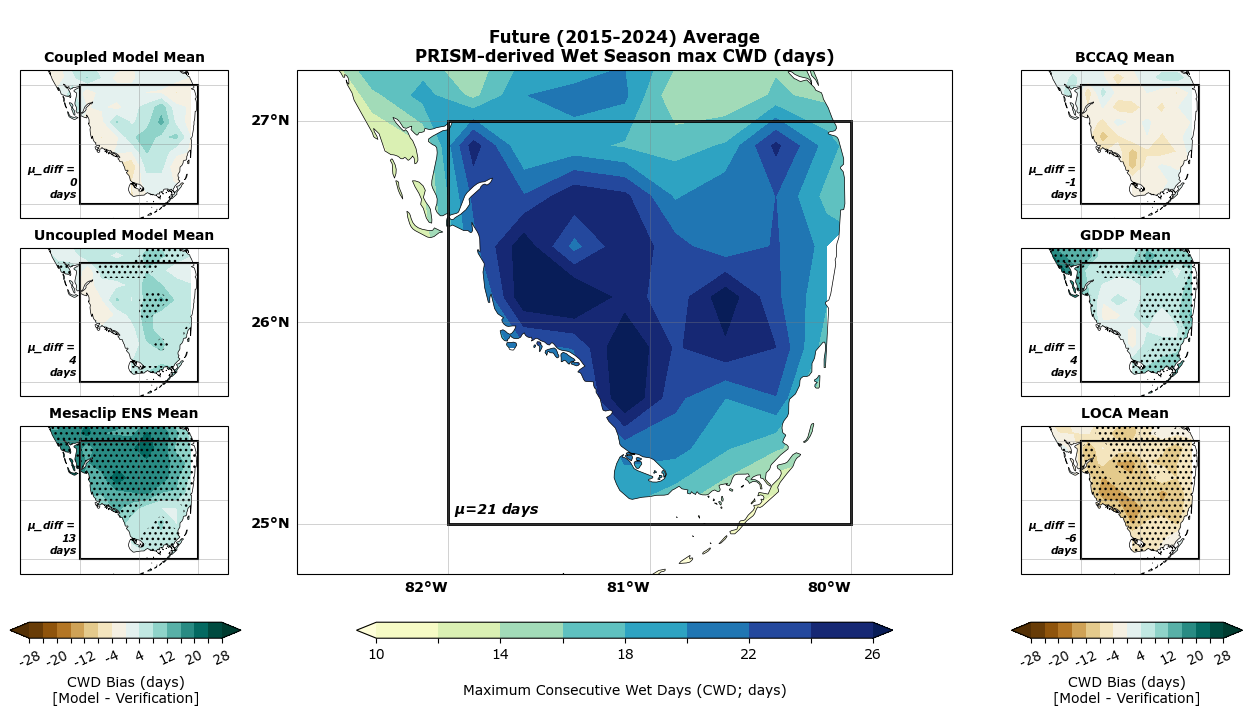

In [18]:
%%time
vmin=10
vmax=26
levels=arange(10,28,2)
labels=["{:.0f}".format(number) for number in levels]
labels[1::2] = [''] * len(labels[1::2])
print(labels)

vminn=-28
vmaxx=28
levelss=arange(-28,32,4)
labelss=["{:.0f}".format(number) for number in levelss]
labelss[1::2] = [''] * len(labelss[1::2])
print(labelss)
if (timeframe=='future'):
    timeframe_caption='SSP-5.85'
else:
    timeframe_caption='Historical'


lon_min = -82.75
lon_max = -79.5
lat_min = 24.75
lat_max = 27.25
mpl.rcParams['font.family'] = "sans-serif"
mpl.rcParams['font.sans-serif'] = "Verdana" 
plt.rcParams['savefig.dpi'] = 300

plot_list=[couple_list,uncouple_list,mesaclip_list,bccaq_list,bcsd_list,loca_list]
label_list=['Coupled Model Mean','Uncoupled Model Mean','Mesaclip ENS Mean','BCCAQ Mean','GDDP Mean','LOCA Mean']

fig, axs = plt.subplots(nrows=3,ncols=5,figsize=(16.5,8),subplot_kw={'projection': ccrs.PlateCarree()})

gs = axs[2, 0].get_gridspec()
rows=arange(0,5,1)
cols=arange(2,9,1) 
rows=arange(0,3,1)
cols=arange(0,5,1) 
# remove the underlying Axes
for i in arange(1,4,1):
    for ax in axs[:,i]:
        ax.remove()

h_plot=nanmean(prism_final,axis=0)
axbig = fig.add_subplot(gs[:,1:4],projection=ccrs.PlateCarree())
v=axbig.contourf(x.coords['lon'].values,x.coords['lat'].values,h_plot,cmap='YlGnBu',
                          transform=ccrs.PlateCarree(),vmin=vmin,vmax=vmax,levels=levels,zorder=0,extend='both')
axbig.set_title('\n'+str(timeframe_label)+' ('+str(yr_i)+'-'+str(yr_f)+') Average\nPRISM-derived Wet Season max CWD (days)',size=12,fontweight='bold')

axbig.add_feature(cfeature.OCEAN, zorder=1, edgecolor='k',linewidth=0.5,facecolor='white')
gl=axbig.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,
                   linewidth=0.5, color='gray', alpha=0.01, linestyle='-',zorder=2)
axbig.set_extent([lon_min,lon_max,lat_min,lat_max])
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'ha':'right','va':'top','fontsize':10,'fontweight':'bold'}
gl.ylabel_style = {'fontsize':10,'fontweight':'bold'}
gl.ylocator = mticker.FixedLocator([25,26,27,28])
gl.xlocator = mticker.FixedLocator([-83,-82,-81,-80])
gl2=axbig.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.5, color='gray', alpha=0.5, linestyle='-',zorder=2)
gl2.top_labels = False
gl2.right_labels = False
gl2.ylocator = mticker.FixedLocator([25,26,27,28])
gl2.xlocator = mticker.FixedLocator([-83,-82,-81,-80])

# Add a red bounding box to the map
# (x, y) = bottom-left corner; width and height in degrees
sq=axbig.add_patch(mpatches.Rectangle(xy=[-82., 25.], width=2, height=2,
                                facecolor='none',
                                edgecolor='black',linestyle='-',
                                linewidth=2,
                                transform=ccrs.PlateCarree()))

#take average of boxed area only
plc_sq=h_plot[2:-6,4:-2]
avg=nanmean(plc_sq) 
stat_text = r'$\mathbfit{\mu}$='+str(int(avg))+' days'
axbig.text(0.24,0.12, stat_text, color='black', fontsize=10, transform=axbig.transAxes,
        fontweight='bold',style='italic')

j=0
for countt,col in enumerate(cols):
    if (col == 0) or (col==4):
        for count,row in enumerate(rows):

            theone=array(plot_list[j])
            
            plot_val=nanmean(theone,axis=0)
            pvals,d,diffs=dr_g_calcs.ttest_bimodial(prism_final,plot_val,lat_arr=x.coords['lat'].values,lon_arr=x.coords['lon'].values)

            axs[row,col].remove()
            ex=fig.add_subplot(gs[row,col],projection=ccrs.PlateCarree())
            g=ex.contourf(x.coords['lon'].values,x.coords['lat'].values,nanmean(diffs,axis=0),cmap='BrBG',
                              transform=ccrs.PlateCarree(),vmin=vminn,vmax=vmaxx,levels=levelss,zorder=0,extend='both')
            pmap=where(pvals<0.05,True,False)
            ex.contourf(x.coords['lon'].values,x.coords['lat'].values,pmap,hatches=['...'],levels=[0.5, 1],colors='none')
            ex.set_title(label_list[j],size=10,fontweight='bold')
            
            ex.add_feature(cfeature.OCEAN, zorder=1, edgecolor='k',linewidth=0.5,facecolor='white')
            gl=ex.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,linewidth=0.5, color='gray', alpha=0.01, linestyle='-',zorder=2,xpadding=2,ypadding=2)
            ex.set_extent([lon_min-0.25,lon_max,lat_min,lat_max])
            gl.ylocator = mticker.FixedLocator([25,26,27,28])
            gl.xlocator = mticker.FixedLocator([-83,-82,-81,-80])
            gl2=ex.gridlines(crs=ccrs.PlateCarree(),draw_labels=False,linewidth=0.5, color='gray', alpha=0.5, linestyle='-',zorder=2)
            gl2.top_labels = False
            gl2.right_labels = False
            gl2.ylocator = mticker.FixedLocator([25,26,27,28])
            gl2.xlocator = mticker.FixedLocator([-83,-82,-81,-80])
            ex.add_patch(mpatches.Rectangle(xy=[-82., 25.], width=2, height=2,
                                facecolor='none',
                                edgecolor='black',linestyle='-',
                                linewidth=1.5,
                                transform=ccrs.PlateCarree()))
            plc_sq=diffs[2:-6,4:-2]
            avg=nanmean(plc_sq) 
            stat_text = r'$\mathbfit{\mu}$_diff ='+' \n'+str(int(avg))+'\ndays'
            ex.text(0.27,0.14, stat_text, color='black', fontsize=7.5, transform=ex.transAxes,
                    fontweight='bold',style='italic',ha='right')
            
            j+=1
    else:
        continue

fig.subplots_adjust(bottom=0.25)
cbar_ax = fig.add_axes([0.14, 0.17, 0.14, 0.02])#[left, bottom, width, height] 
cbar=fig.colorbar(g,orientation='horizontal',cax=cbar_ax,extendfrac=0.1)
cbar.ax.set_xticks(levelss,labels=labelss)
cbar.ax.tick_params(labelsize=9.5,rotation=25)
cbar.set_label(label='CWD Bias (days)\n[Model - Verification]', size=10)

cbar_ax = fig.add_axes([0.35, 0.17, 0.325, 0.02])#[left, bottom, width, height] 
cbar=fig.colorbar(v,orientation='horizontal',cax=cbar_ax,extendfrac=0.04)
cbar.ax.set_xticks(levels,labels=labels)
cbar.ax.tick_params(labelsize=10)
cbar.set_label(label='\nMaximum Consecutive Wet Days (CWD; days)',size=10)

cbar_ax = fig.add_axes([0.747, 0.17, 0.14, 0.02])#[left, bottom, width, height] 
cbar=fig.colorbar(g,orientation='horizontal',cax=cbar_ax,extendfrac=0.1)
cbar.ax.set_xticks(levelss,labels=labelss)
cbar.ax.tick_params(labelsize=9.5,rotation=25)
cbar.set_label(label='CWD Bias (days)\n[Model - Verification]', size=10)

fig.subplots_adjust(wspace=-0.1)